# Detecção de anomalias — RefleX (imagens de difração de raios X)

Notebook de experimentação. Reaproveita os módulos de `src/` (config, dataset, transforms, model) para que o que for validado aqui possa ser promovido para scripts depois.

**Estrutura**
1. Setup
2. Exploração dos dados
3. Dataloaders e augmentations
4. Treino (baseline: ResNet50 congelada + nova cabeça)
5. Avaliação na validação/teste (AP, limiares por classe)
6. Análise de erros
7. Log de experimentos e próximos passos

## 1. Setup

In [1]:
import sys, random
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

from src import config as cfg
from src.config import CLASSES, DEVICE
from src.dataset import RefleXDataset
from src.model import build_model
from src.transforms import train_transform, eval_transform

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("device:", DEVICE, "| torch", torch.__version__)
print("classes:", CLASSES)

device: cuda | torch 2.14.0+cu130
classes: ['ice_ring', 'diffuse_scattering', 'background_ring', 'non_uniform_detector', 'loop_scattering', 'strong_background', 'artifact']


## 2. Exploração dos dados

In [2]:
train_df = pd.read_csv(cfg.LABELS_TRAIN_CSV)
val_df = pd.read_csv(cfg.LABELS_VAL_CSV)
test_df = pd.read_csv(cfg.LABELS_TEST_CSV)

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

# Frequência de cada classe por split (% de imagens positivas)
freq = pd.DataFrame({
    name: df[CLASSES].mean() * 100
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]
}).round(1)
freq["n_train"] = train_df[CLASSES].sum().astype(int)
freq.sort_values("n_train", ascending=False)

{'train': 5048, 'val': 631, 'test': 632}


,train,val,test,n_train
background_ring,60.5,60.2,61.6,3054
strong_background,46.6,49.3,47.5,2350
loop_scattering,46.4,44.7,41.8,2340
non_uniform_detector,33.7,36.6,35.4,1700
artifact,15.6,15.4,19.9,785
ice_ring,7.6,6.0,7.3,383
diffuse_scattering,7.2,6.2,7.0,364


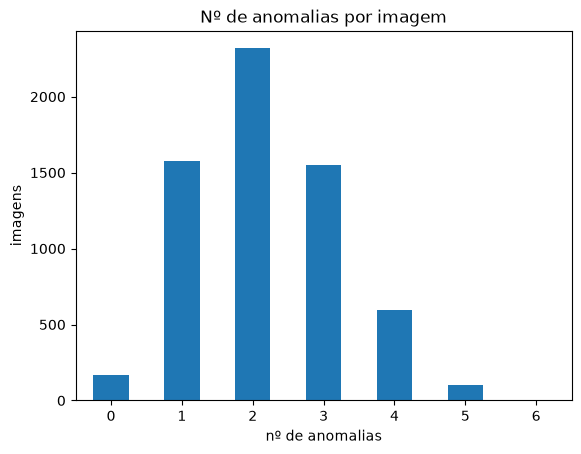

In [3]:
# Número de anomalias por imagem
all_df = pd.concat([train_df, val_df, test_df])
n_anom = all_df[CLASSES].sum(axis=1)
n_anom.value_counts().sort_index().plot.bar(title="Nº de anomalias por imagem", rot=0)
plt.xlabel("nº de anomalias"); plt.ylabel("imagens"); plt.show()

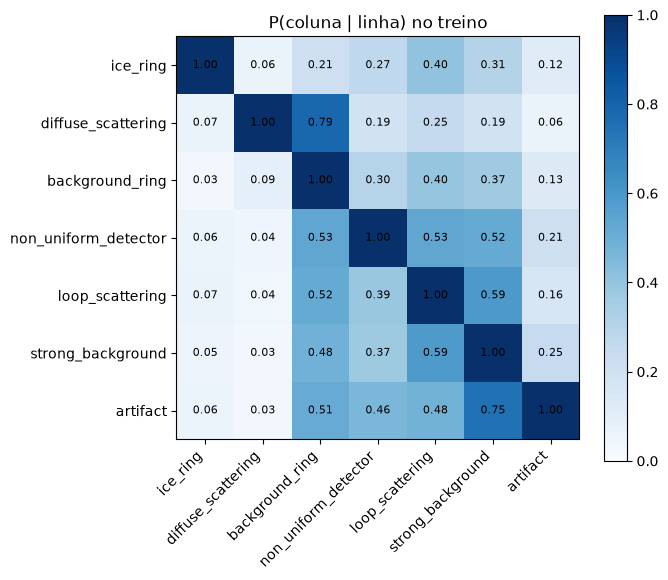

In [4]:
# Co-ocorrência: P(coluna | linha) — dado que a linha está presente, quão frequente é a coluna
Y = train_df[CLASSES].values
co = Y.T @ Y
cond = pd.DataFrame(co / np.diag(co)[:, None], index=CLASSES, columns=CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cond.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cond.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("P(coluna | linha) no treino")
plt.colorbar(im); plt.tight_layout(); plt.show()

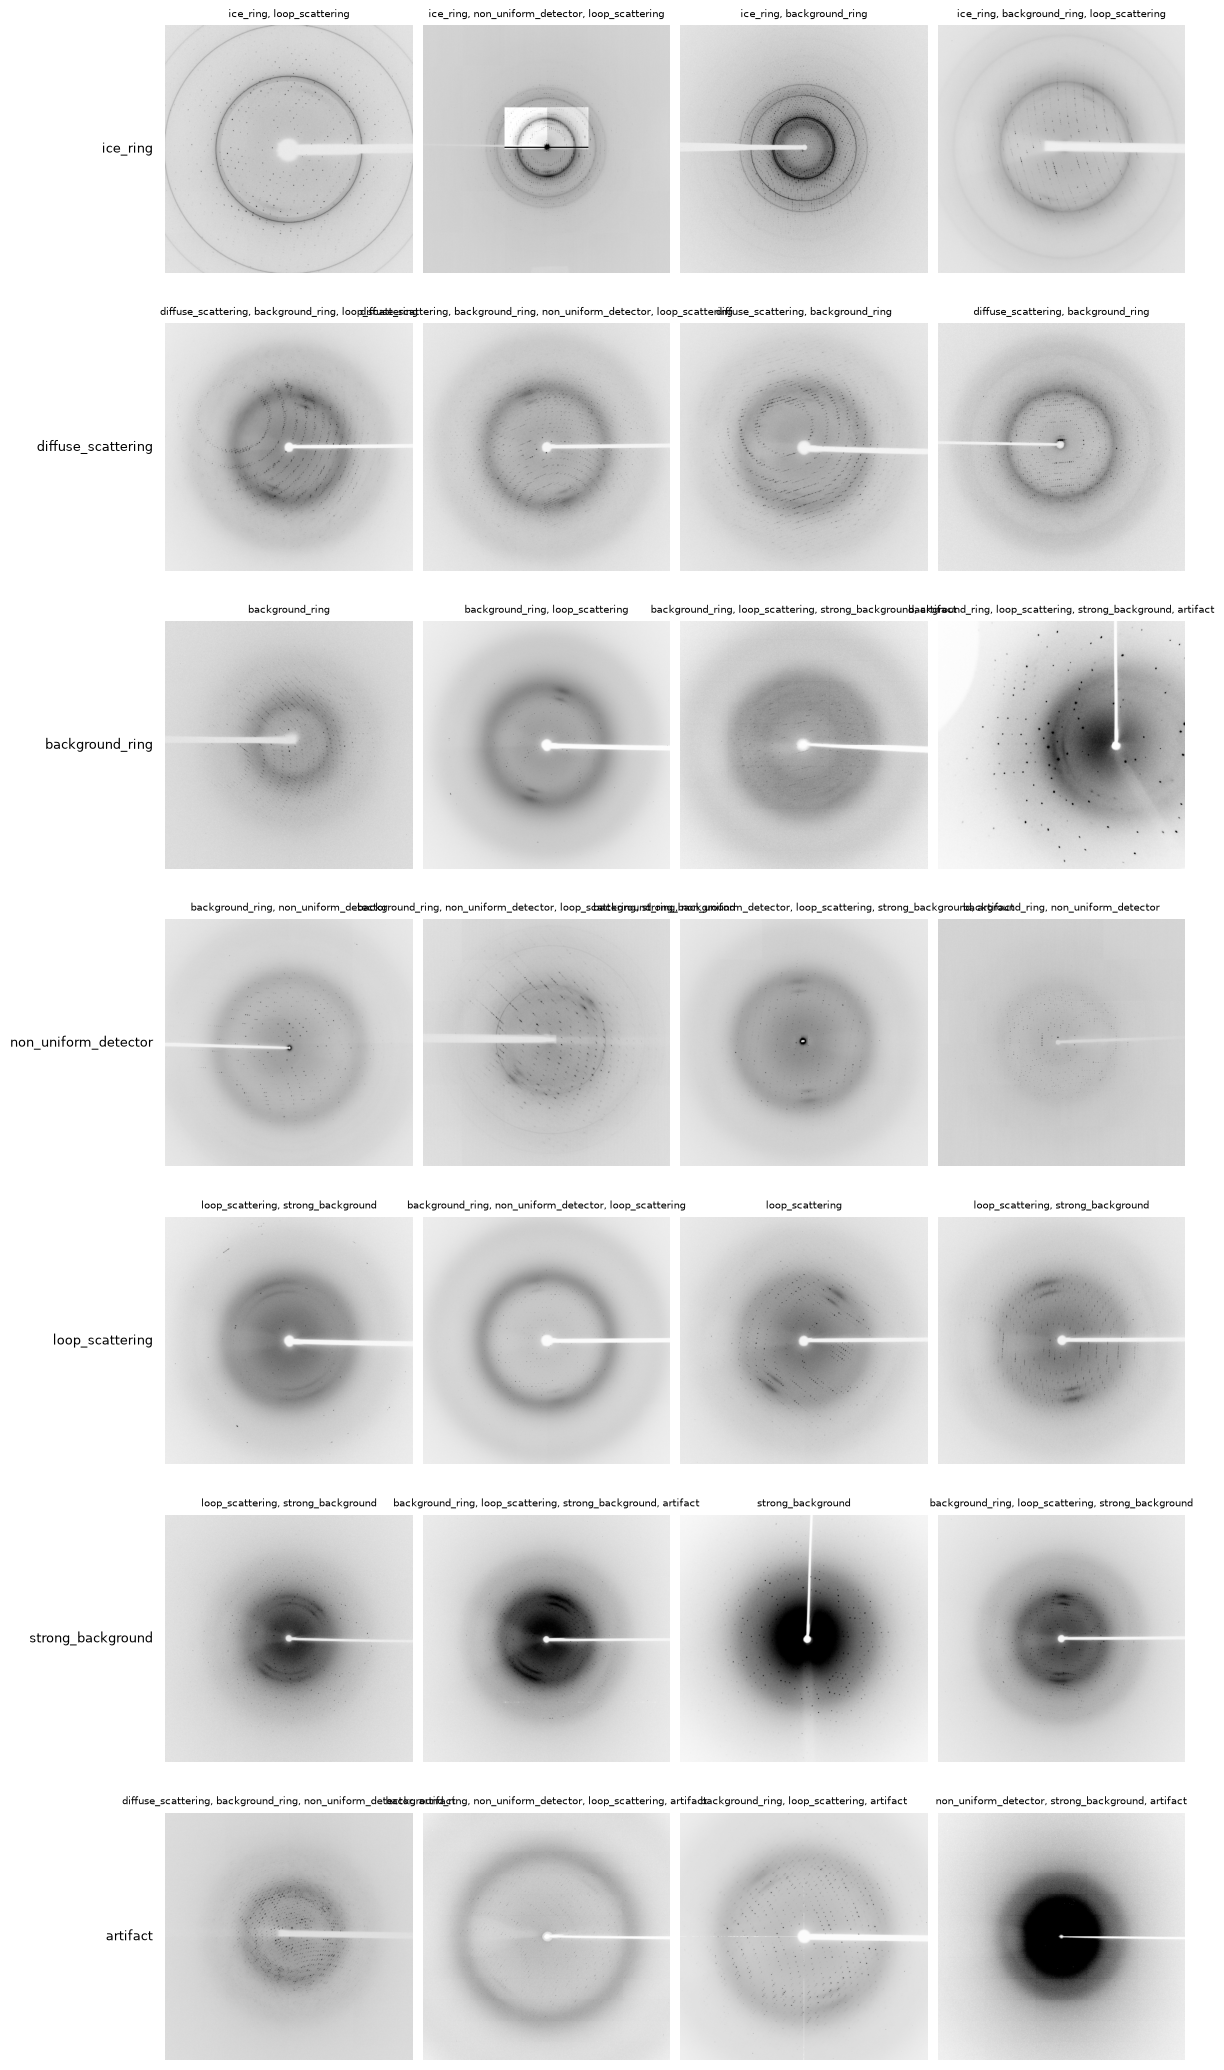

In [5]:
# Exemplos de imagens por classe (positivas para aquela classe)
ds_raw = RefleXDataset(cfg.LABELS_TRAIN_CSV)  # sem transform -> PIL
N_EX = 4
fig, axes = plt.subplots(len(CLASSES), N_EX, figsize=(3 * N_EX, 3 * len(CLASSES)))
rng = np.random.default_rng(SEED)
for r, cls in enumerate(CLASSES):
    idxs = rng.choice(np.where(train_df[cls] == 1)[0], N_EX, replace=False)
    for c, i in enumerate(idxs):
        img, _ = ds_raw[i]
        axes[r, c].imshow(img, cmap="gray"); axes[r, c].axis("off")
        active = [k for k in CLASSES if train_df.iloc[i][k] == 1]
        axes[r, c].set_title(", ".join(active), fontsize=7)
    axes[r, 0].text(-0.05, 0.5, cls, transform=axes[r, 0].transAxes, ha="right", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 3. Dataloaders e augmentations

In [25]:
# Hiperparâmetros do experimento (edite aqui; defaults vêm de src/config.py)
EXP = dict(
    name="baseline_resnet50_frozen",
    batch_size=cfg.BATCH_SIZE,
    num_epochs=cfg.NUM_EPOCHS,
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    freeze_backbone=True,
    num_workers=4,  # 0 evita problemas de multiprocessing no Windows/Jupyter; suba p/ 2-4 se quiser
)
# IMAGE_SIZE é lido de src/config.py pelo src/transforms.py; para mudar, edite o config e reinicie o kernel.

QUICK_RUN = False  # True: 2 épocas e subconjunto pequeno, só para validar o pipeline
if QUICK_RUN:
    EXP["num_epochs"] = 2
EXP

{'name': 'baseline_resnet50_frozen',
 'batch_size': 16,
 'num_epochs': 30,
 'lr': 0.0003,
 'weight_decay': 0.0001,
 'freeze_backbone': True,
 'num_workers': 4}

In [26]:
train_ds = RefleXDataset(cfg.LABELS_TRAIN_CSV, transform=train_transform)
val_ds = RefleXDataset(cfg.LABELS_VAL_CSV, transform=eval_transform)
test_ds = RefleXDataset(cfg.LABELS_TEST_CSV, transform=eval_transform)

if QUICK_RUN:
    train_ds_used = Subset(train_ds, range(256))
    val_ds_used = Subset(val_ds, range(128))
else:
    train_ds_used, val_ds_used = train_ds, val_ds

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=EXP["batch_size"], shuffle=shuffle,
                      num_workers=EXP["num_workers"], pin_memory=DEVICE.type == "cuda")

train_loader = make_loader(train_ds_used, True)
val_loader = make_loader(val_ds_used, False)
print(len(train_loader), "batches de treino |", len(val_loader), "de validação")

316 batches de treino | 40 de validação


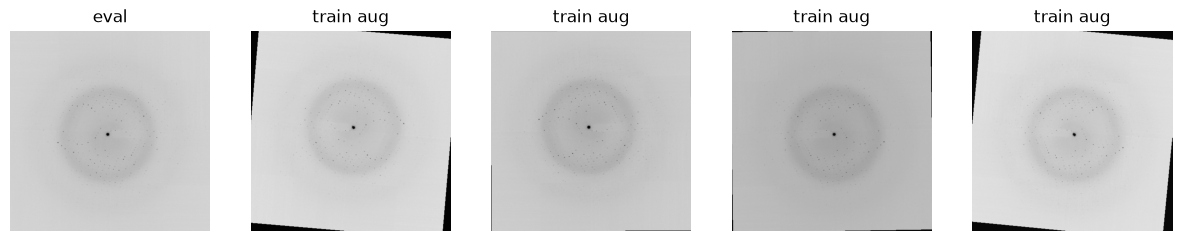

In [27]:
# Efeito das augmentations sobre uma mesma imagem
mean = torch.tensor(cfg.IMAGENET_MEAN)[:, None, None]
std = torch.tensor(cfg.IMAGENET_STD)[:, None, None]
def denorm(t): return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

img, _ = ds_raw[0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
axes[0].imshow(denorm(eval_transform(img))); axes[0].set_title("eval")
for a in axes[1:]:
    a.imshow(denorm(train_transform(img))); a.set_title("train aug")
for a in axes: a.axis("off")
plt.show()

## 4. Treino

Baseline igual a `src/train.py`: ResNet50 pré-treinada com backbone congelado, `BCEWithLogitsLoss` com `pos_weight` (negativos/positivos por classe), AdamW. `run_epoch` e `compute_pos_weight` são importados de `src.train`, então o comportamento é idêntico ao do script.

In [28]:
from src.train import compute_pos_weight, run_epoch

def train_model(exp, train_loader, val_loader, pos_weight, ckpt_name=None):
    model = build_model(pretrained=True, freeze_backbone=exp["freeze_backbone"]).to(DEVICE)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=exp["lr"], weight_decay=exp["weight_decay"],
    )
    history, best_map, best_state = [], -1.0, None
    for epoch in range(1, exp["num_epochs"] + 1):
        tr_loss, tr_ap, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_ap, _ = run_epoch(model, val_loader, criterion)
        row = dict(epoch=epoch, train_loss=tr_loss, val_loss=va_loss,
                   train_mAP=tr_ap.mean().item(), val_mAP=va_ap.mean().item())
        row.update({f"AP_{c}": v for c, v in zip(CLASSES, va_ap.tolist())})
        history.append(row)
        print(f"ep {epoch:02d} | train_loss {tr_loss:.4f} val_loss {va_loss:.4f} | val_mAP {row['val_mAP']:.4f}")
        if row["val_mAP"] > best_map:
            best_map = row["val_mAP"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    if ckpt_name and not QUICK_RUN:
        cfg.CHECKPOINTS_DIR.mkdir(exist_ok=True)
        torch.save(best_state, cfg.CHECKPOINTS_DIR / ckpt_name)
    return model, pd.DataFrame(history)

pos_weight = compute_pos_weight(train_ds)
print(dict(zip(CLASSES, pos_weight.cpu().numpy().round(2))))

{'ice_ring': np.float32(12.18), 'diffuse_scattering': np.float32(12.87), 'background_ring': np.float32(0.65), 'non_uniform_detector': np.float32(1.97), 'loop_scattering': np.float32(1.16), 'strong_background': np.float32(1.15), 'artifact': np.float32(5.43)}


In [29]:
model, hist = train_model(EXP, train_loader, val_loader, pos_weight, ckpt_name=f"{EXP['name']}.pt")
hist

ep 01 | train_loss 0.8539 val_loss 0.7403 | val_mAP 0.6962


ep 02 | train_loss 0.7451 val_loss 0.6802 | val_mAP 0.7231


ep 03 | train_loss 0.6974 val_loss 0.6481 | val_mAP 0.7389


ep 04 | train_loss 0.6674 val_loss 0.6258 | val_mAP 0.7447


ep 05 | train_loss 0.6475 val_loss 0.6114 | val_mAP 0.7491


...

ep 27 | train_loss 0.5425 val_loss 0.5252 | val_mAP 0.7930


ep 28 | train_loss 0.5417 val_loss 0.5235 | val_mAP 0.7930


ep 29 | train_loss 0.5466 val_loss 0.5227 | val_mAP 0.7949


ep 30 | train_loss 0.5362 val_loss 0.5258 | val_mAP 0.7955


,epoch,train_loss,val_loss,train_mAP,val_mAP,AP_ice_ring,AP_diffuse_scattering,AP_background_ring,AP_non_uniform_detector,AP_loop_scattering,AP_strong_background,AP_artifact
0,1,0.853947,0.740256,0.580159,0.696212,0.882254,0.309413,0.845078,0.605486,0.718718,0.941505,0.571029
1,2,0.745133,0.680216,0.661419,0.723130,0.874080,0.385468,0.881037,0.627692,0.733934,0.950068,0.609629
2,3,0.697367,0.648144,0.680873,0.738857,0.890973,0.414175,0.893737,0.648650,0.742187,0.956430,0.625850
3,4,0.667426,0.625760,0.695508,0.744694,0.890518,0.422695,0.902700,0.662695,0.745666,0.957822,0.630762
4,5,0.647530,0.611440,0.703830,0.749097,0.893496,0.431853,0.903294,0.664267,0.753100,0.961932,0.635739
5,6,0.633609,0.588724,0.712872,0.755373,0.894766,0.475363,0.904141,0.660815,0.757797,0.964510,0.630219
6,7,0.625125,0.595986,0.714510,0.760414,0.901284,0.455432,0.912900,0.681207,0.760456,0.964381,0.647241
7,8,0.612737,0.581565,0.723911,0.764875,0.899207,0.491869,0.909059,0.681390,0.766800,0.965770,0.640028
8,9,0.606101,0.575160,0.723461,0.768088,0.904794,0.489247,0.913936,0.685118,0.769074,0.966880,0.647569
9,10,0.601709,0.567078,0.728375,0.769731,0.898867,0.497905,0.915549,0.686806,0.775747,0.967170,0.646076


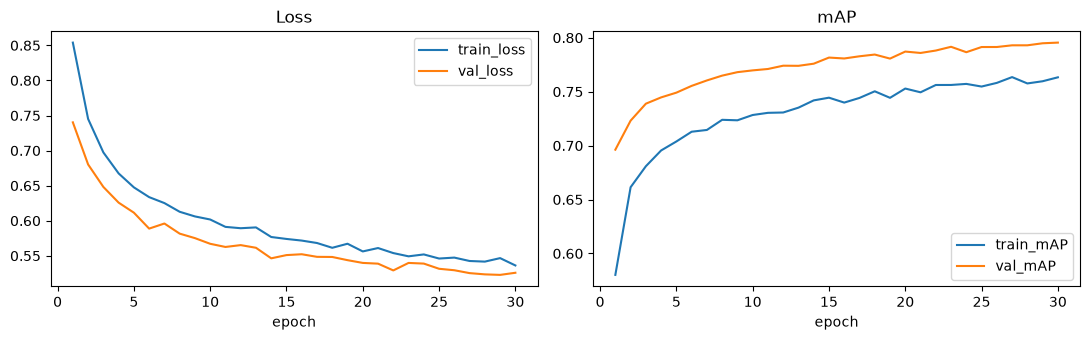

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
hist.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax[0], title="Loss")
hist.plot(x="epoch", y=["train_mAP", "val_mAP"], ax=ax[1], title="mAP")
plt.tight_layout(); plt.show()

## 5. Avaliação

Coleta as probabilidades do modelo, mede AP por classe e escolhe um **limiar por classe na validação** (maximizando F1). O teste só deve ser usado no final, com os limiares já fixados — não ajuste nada olhando o teste.

In [31]:
@torch.no_grad()
def predict_probs(model, ds, batch_size=32):
    model.eval()
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=EXP["num_workers"])
    probs, ys = [], []
    for x, y in tqdm(loader, leave=False):
        probs.append(torch.sigmoid(model(x.to(DEVICE))).cpu()); ys.append(y)
    return torch.cat(probs).numpy(), torch.cat(ys).numpy().astype(int)

p_val, y_val = predict_probs(model, val_ds_used)  # em QUICK_RUN é um subconjunto
print(p_val.shape)

  0%|          | 0/20 [00:00<?, ?it/s]

(631, 7)


In [32]:
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

def best_thresholds(p, y):
    ths = []
    for j in range(p.shape[1]):
        if y[:, j].sum() == 0:
            ths.append(0.5); continue
        prec, rec, th = precision_recall_curve(y[:, j], p[:, j])
        f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)
        ths.append(float(th[np.argmax(f1)]))
    return np.array(ths)

def report(p, y, ths):
    rows = []
    for j, c in enumerate(CLASSES):
        has_pos = y[:, j].sum() > 0
        rows.append(dict(
            classe=c, positivos=int(y[:, j].sum()),
            AP=average_precision_score(y[:, j], p[:, j]) if has_pos else np.nan,
            F1_0_5=f1_score(y[:, j], p[:, j] >= 0.5, zero_division=0),
            limiar=ths[j],
            F1_limiar=f1_score(y[:, j], p[:, j] >= ths[j], zero_division=0),
        ))
    df = pd.DataFrame(rows).set_index("classe")
    df.loc["MÉDIA"] = df.mean(numeric_only=True)
    return df.round(3)

thresholds = best_thresholds(p_val, y_val)
report(p_val, y_val, thresholds)

,positivos,AP,F1_0_5,limiar,F1_limiar
classe,,,,,
ice_ring,38.000,0.905,0.750,0.950,0.892
diffuse_scattering,39.000,0.573,0.290,0.857,0.579
background_ring,380.000,0.933,0.855,0.323,0.861
non_uniform_detector,231.000,0.710,0.629,0.438,0.648
loop_scattering,282.000,0.805,0.712,0.395,0.725
strong_background,311.000,0.971,0.886,0.345,0.906
artifact,97.000,0.672,0.616,0.432,0.622
MÉDIA,196.857,0.795,0.677,0.534,0.747


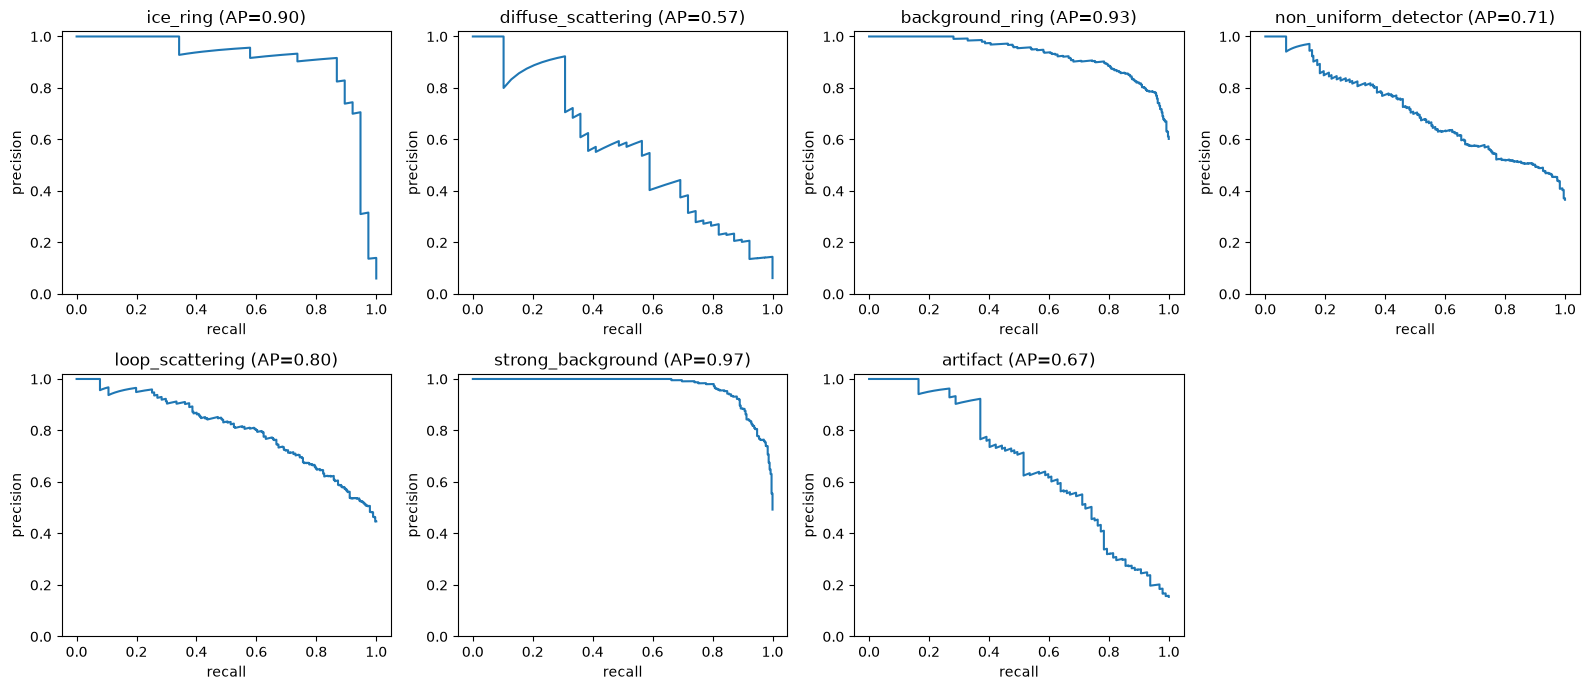

In [33]:
# Curvas Precision-Recall por classe (validação)
fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.ravel()
for j, c in enumerate(CLASSES):
    if y_val[:, j].sum():
        pr, rc, _ = precision_recall_curve(y_val[:, j], p_val[:, j])
        axes[j].plot(rc, pr)
        ap = average_precision_score(y_val[:, j], p_val[:, j])
    else:
        ap = float("nan")
    axes[j].set_title(f"{c} (AP={ap:.2f})")
    axes[j].set_xlabel("recall"); axes[j].set_ylabel("precision"); axes[j].set_ylim(0, 1.02)
axes[-1].axis("off"); plt.tight_layout(); plt.show()

In [34]:
# Avaliação final no TESTE (rodar só quando o experimento estiver fechado)
RUN_TEST = False
if RUN_TEST:
    p_test, y_test = predict_probs(model, test_ds)
    display(report(p_test, y_test, thresholds))

## 6. Análise de erros

Onde o modelo erra na validação: quais classes são preditas indevidamente quando outra é perdida, e exemplos de falsos positivos/negativos.

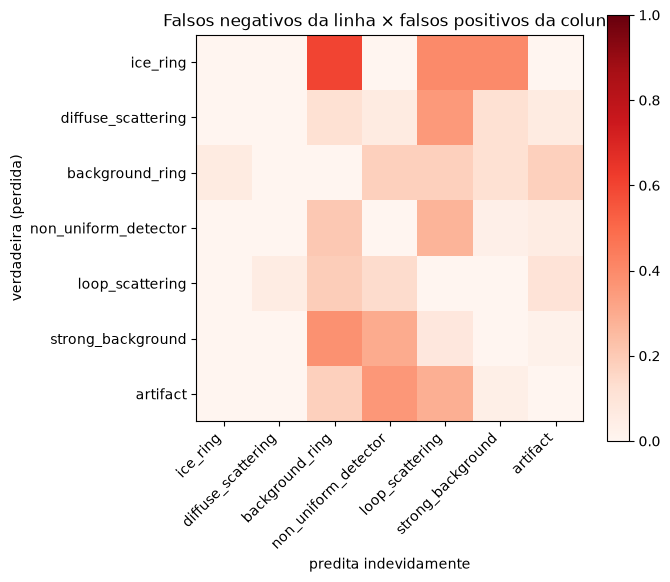

In [35]:
# Nos falsos negativos da classe i, qual fração teve a classe j predita indevidamente?
pred_val = (p_val >= thresholds).astype(int)
conf = np.zeros((len(CLASSES), len(CLASSES)))
for i in range(len(CLASSES)):
    fn = (y_val[:, i] == 1) & (pred_val[:, i] == 0)
    if fn.sum():
        conf[i] = (pred_val[fn] * (y_val[fn] == 0)).sum(0) / fn.sum()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right"); ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel("predita indevidamente"); ax.set_ylabel("verdadeira (perdida)")
ax.set_title("Falsos negativos da linha × falsos positivos da coluna")
plt.colorbar(im); plt.tight_layout(); plt.show()

ice_ring: 5 FN no total; mostrando 5


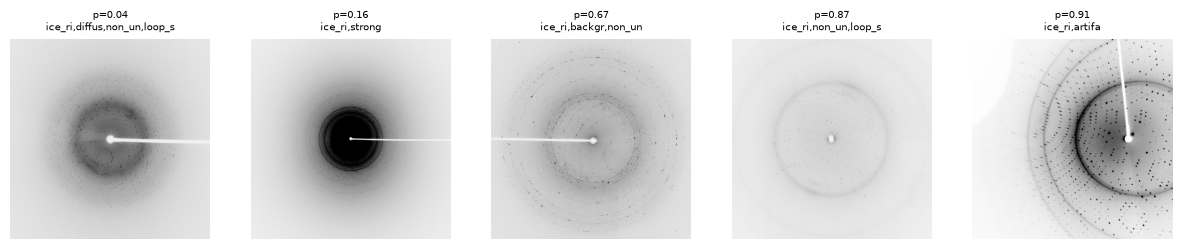

ice_ring: 3 FP no total; mostrando 3


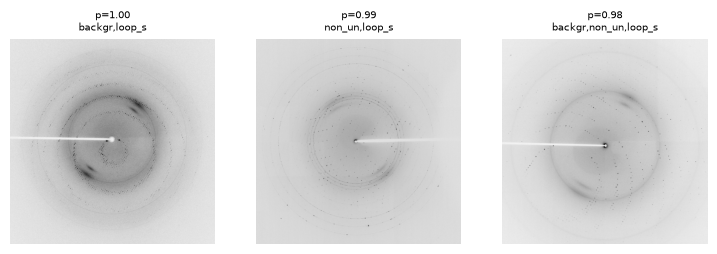

In [36]:
def show_errors(cls, kind="FN", n=8):
    j = CLASSES.index(cls)
    base = val_ds  # val_ds_used é um Subset(range(N)) ou o próprio val_ds: os índices coincidem
    if kind == "FN":
        mask = (y_val[:, j] == 1) & (pred_val[:, j] == 0)
    else:
        mask = (y_val[:, j] == 0) & (pred_val[:, j] == 1)
    idxs = np.where(mask)[0]
    order = np.argsort(-p_val[idxs, j]) if kind == "FP" else np.argsort(p_val[idxs, j])
    idxs = idxs[order][:n]
    print(f"{cls}: {mask.sum()} {kind} no total; mostrando {len(idxs)}")
    if len(idxs) == 0:
        return
    fig, axes = plt.subplots(1, len(idxs), figsize=(3 * len(idxs), 3.4), squeeze=False)
    for a, i in zip(axes[0], idxs):
        row = base.df.iloc[i]
        img = Image.open(base.images_dir / f"{row['image']}{base.image_ext}")
        a.imshow(img, cmap="gray"); a.axis("off")
        a.set_title(f"p={p_val[i, j]:.2f}\n" + ",".join(c[:6] for c in CLASSES if row[c] == 1), fontsize=7)
    plt.show()

show_errors("ice_ring", "FN")
show_errors("ice_ring", "FP")

## 7. Log de experimentos e próximos passos

Registre cada rodada aqui para comparar (mAP de validação, o que mudou).

In [37]:
results = []  # acumula um dict por experimento

def log_experiment(exp, hist):
    best = hist.loc[hist.val_mAP.idxmax()]
    results.append({**exp, "best_epoch": int(best.epoch), "val_mAP": round(best.val_mAP, 4)})
    return pd.DataFrame(results).set_index("name")

log_experiment(EXP, hist)

,batch_size,num_epochs,lr,weight_decay,freeze_backbone,num_workers,best_epoch,val_mAP
name,,,,,,,,
baseline_resnet50_frozen,16,30,0.0003,0.0001,True,4,30,0.7955


**Ideias a testar, em ordem sugerida**
- [ ] Treino completo do baseline (`QUICK_RUN = False`) e limiares por classe
- [ ] Descongelar o backbone (`freeze_backbone=False`) com LR menor (~1e-4 → 3e-5)
- [ ] `IMAGE_SIZE` maior (768/1024) para anéis de gelo e espalhamento difuso
- [ ] Focal loss no lugar de `BCEWithLogitsLoss` + `pos_weight`
- [ ] Outras arquiteturas (EfficientNet, ConvNeXt)
- [ ] Revisar rótulos duvidosos pela análise de erros (seção 6)
- [ ] Rodar o teste uma única vez com o melhor modelo (`RUN_TEST = True`)

In [38]:
cfg.CHECKPOINTS_DIR.mkdir(exist_ok=True)
torch.save(model.state_dict(), cfg.CHECKPOINTS_DIR / "baseline_resnet50_frozen.pt")
